In [16]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

BIN_DIR  = Path("../outputs/unet_bin")
OUT_HOUGH = Path("../outputs/hough_overlay")
OUT_EDGES = Path("../outputs/edges_roi")
OUT_HOUGH.mkdir(parents=True, exist_ok=True)
OUT_EDGES.mkdir(parents=True, exist_ok=True)


In [17]:
def roi_edges(edges):
    H, W = edges.shape
    roi = np.zeros_like(edges)

    poly = np.array([[
        (int(0.05 * W), H),
        (int(0.40 * W), int(0.55 * H)),
        (int(0.60 * W), int(0.55 * H)),
        (int(0.95 * W), H),
    ]], dtype=np.int32)

    cv2.fillPoly(roi, poly, 255)
    return cv2.bitwise_and(edges, roi)

def hough_lines(edges_roi):
    return cv2.HoughLinesP(
        edges_roi,
        rho=1,
        theta=np.pi / 180,
        threshold=20,
        minLineLength=25,
        maxLineGap=50,
    )


In [18]:
def split_left_right(lines, W):
    left, right = [], []
    if lines is None:
        return None, None

    for x1, y1, x2, y2 in lines.reshape(-1, 4):
        if x2 == x1:
            continue
        m = (y2 - y1) / (x2 - x1)
        if m < -0.3 and x1 < W * 0.7 and x2 < W * 0.7:
            left.append([x1, y1, x2, y2])
        elif m > 0.3 and x1 > W * 0.3 and x2 > W * 0.3:
            right.append([x1, y1, x2, y2])

    left = np.array(left) if len(left) else None
    right = np.array(right) if len(right) else None
    return left, right

def average_lane_line(lines):
    if lines is None:
        return None
    ms, bs = [], []
    for x1, y1, x2, y2 in lines:
        if x2 == x1:
            continue
        m = (y2 - y1) / (x2 - x1)
        b = y1 - m * x1
        ms.append(m)
        bs.append(b)
    if len(ms) == 0:
        return None
    return float(np.mean(ms)), float(np.mean(bs))

def draw_avg_line(img_bgr, mb, y_bottom, y_top, thickness=5):
    if mb is None:
        return img_bgr
    m, b = mb
    if abs(m) < 1e-6:
        return img_bgr
    x_bottom = int((y_bottom - b) / m)
    x_top = int((y_top - b) / m)
    cv2.line(img_bgr, (x_bottom, y_bottom), (x_top, y_top), (0,0,255), thickness)
    return img_bgr


In [19]:
from pathlib import Path
import cv2

BIN_DIR = Path("../outputs/unet_bin")
VIS_DIR = Path("../outputs/vis")

mask_path = BIN_DIR / "0530__1492626047222176976_0__13_bin.png"
orig_path = VIS_DIR / "0530__1492626047222176976_0__13_orig.png"

mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
assert mask is not None, f"Cannot read mask: {mask_path}"

frame_resized = cv2.imread(str(orig_path))
assert frame_resized is not None, f"Cannot read saved original: {orig_path}"


In [20]:
# ---------- HOUGH PROCESSING CELL (MUST RUN BEFORE VISUALIZATION) ----------

# Edge detection on binary mask
edges = cv2.Canny(mask, 30, 100)

# Apply region of interest
edges_roi = roi_edges(edges)

# Hough line detection
lines = hough_lines(edges_roi)

# Split and average lanes
H, W = edges_roi.shape
left_lines, right_lines = split_left_right(lines, W)

left_mb = average_lane_line(left_lines)
right_mb = average_lane_line(right_lines)

# Draw result on original image
out = frame_resized.copy()
y_bottom = H - 1
y_top = int(H * 0.55)

out = draw_avg_line(out, left_mb, y_bottom, y_top)
out = draw_avg_line(out, right_mb, y_bottom, y_top)

# Save output
save_path = OUT_HOUGH / (mask_path.stem + "_hough.png")
cv2.imwrite(str(save_path), out)

print("Saved Hough result to:", save_path)


Saved Hough result to: ..\outputs\hough_overlay\0530__1492626047222176976_0__13_bin_hough.png


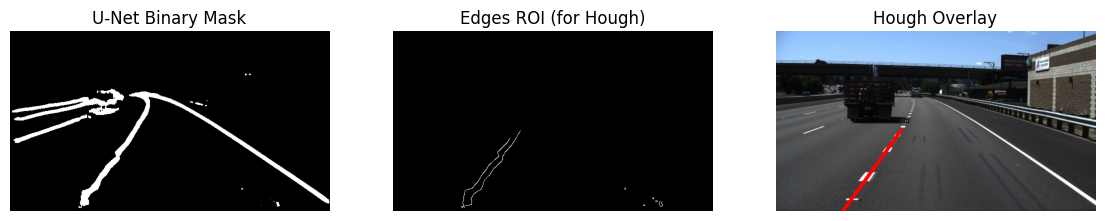

In [21]:
plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.title("U-Net Binary Mask"); plt.imshow(mask, cmap="gray"); plt.axis("off")
plt.subplot(1,3,2); plt.title("Edges ROI (for Hough)"); plt.imshow(edges_roi, cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title("Hough Overlay"); plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.show()
